# 02 — Statistical Analysis

**Project:** Gaming Launch Intelligence — Predicting Commercial Success and Optimising Platform & Launch Strategy

**Objective:** Apply formal statistical tests to validate the exploratory findings from Notebook 01 and the SQL analysis, providing quantitative evidence for each business recommendation.

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, pearsonr, mannwhitneyu
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

FIGURES_DIR = '../outputs/figures'
SQL_RESULTS_DIR = '../../SQL_Analysis/Result'

In [2]:
# Load cleaned dataset from Notebook 01
df = pd.read_csv('../outputs/cleaned_dataset.csv', parse_dates=['release_date', 'last_update'])
df['release_year'] = df['release_date'].dt.year.astype('Int64')

# Analysis window
ANALYSIS_START = 2006
ANALYSIS_END = 2018
df_scoped = df[(df['release_year'] >= ANALYSIS_START) & (df['release_year'] <= ANALYSIS_END)].copy()

print(f'Full dataset: {len(df):,} rows')
print(f'Analysis window ({ANALYSIS_START}-{ANALYSIS_END}): {len(df_scoped):,} rows')

Full dataset: 18,850 rows
Analysis window (2006-2018): 12,713 rows


## 2. Distribution Analysis

### Q1: Are game sales normally distributed?

This determines whether we should use parametric (t-test, ANOVA) or non-parametric (Mann-Whitney, Kruskal-Wallis) tests throughout the analysis.

In [3]:
# Shapiro-Wilk test on a random sample (test is limited to n <= 5000)
sample = df_scoped['total_sales'].dropna().sample(n=min(5000, len(df_scoped)), random_state=42)
stat, p_value = shapiro(sample)

print('Shapiro-Wilk Normality Test')
print(f'  Statistic: {stat:.6f}')
print(f'  p-value:   {p_value:.2e}')
print(f'  Result:    {"NOT normally distributed" if p_value < 0.05 else "Normally distributed"} (alpha=0.05)')
print()
print(f'  Skewness:  {df_scoped["total_sales"].skew():.2f}')
print(f'  Kurtosis:  {df_scoped["total_sales"].kurtosis():.2f}')
print()
print('Implication: Non-parametric tests (Kruskal-Wallis, Spearman) are required.')

Shapiro-Wilk Normality Test
  Statistic: 0.342819
  p-value:   3.59e-86
  Result:    NOT normally distributed (alpha=0.05)

  Skewness:  9.11
  Kurtosis:  125.48

Implication: Non-parametric tests (Kruskal-Wallis, Spearman) are required.


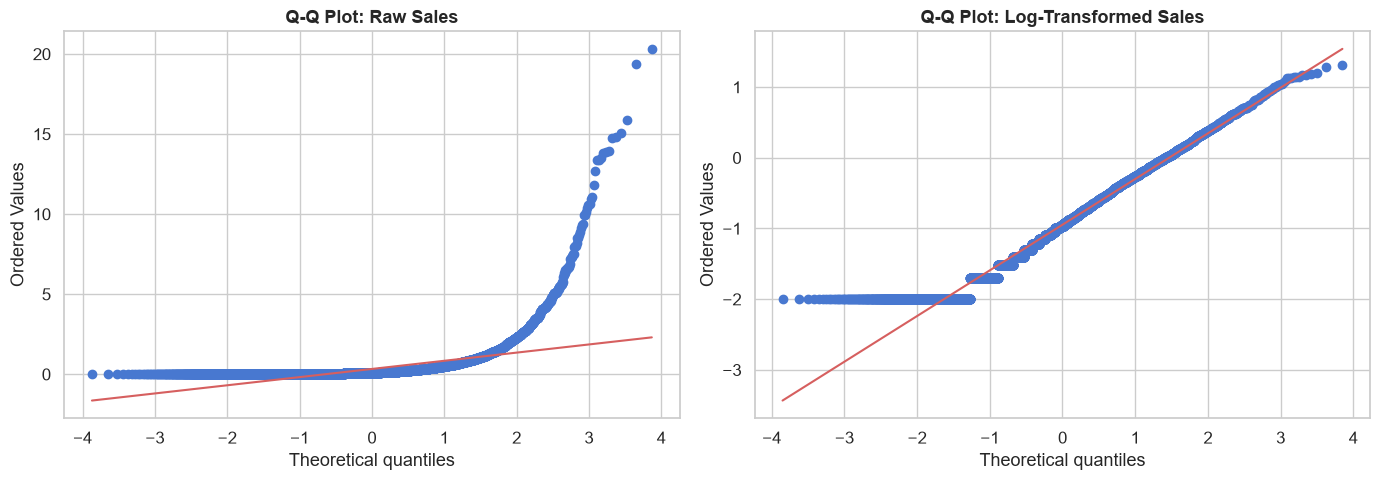

In [4]:
# Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw sales
stats.probplot(df_scoped['total_sales'].dropna(), dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Raw Sales', fontweight='bold')

# Log-transformed sales
log_sales = np.log10(df_scoped['total_sales'][df_scoped['total_sales'] > 0])
stats.probplot(log_sales, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Log-Transformed Sales', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/qq_plots.png', bbox_inches='tight')
plt.show()

## 3. Platform Sales Comparison

### Q2: Are sales differences between platforms statistically significant?

Using Kruskal-Wallis (non-parametric ANOVA) to test whether at least one platform's sales distribution differs significantly from the others, followed by pairwise Mann-Whitney U tests for the top platforms.

In [5]:
# Kruskal-Wallis test across all platforms
platform_groups = [
    group['total_sales'].values
    for _, group in df_scoped.groupby('console')
    if len(group) >= 20
]

h_stat, p_value = kruskal(*platform_groups)
print('Kruskal-Wallis Test: Platform Sales Differences')
print(f'  H-statistic: {h_stat:.2f}')
print(f'  p-value:     {p_value:.2e}')
print(f'  Result:      {"Significant" if p_value < 0.05 else "Not significant"} differences exist between platforms')

Kruskal-Wallis Test: Platform Sales Differences
  H-statistic: 2097.20
  p-value:     0.00e+00
  Result:      Significant differences exist between platforms


In [6]:
# Pairwise Mann-Whitney U tests for the top 8 platforms
from itertools import combinations

top_platforms = df_scoped.groupby('console')['total_sales'].sum().nlargest(8).index.tolist()
pairwise_results = []

for p1, p2 in combinations(top_platforms, 2):
    g1 = df_scoped[df_scoped['console'] == p1]['total_sales']
    g2 = df_scoped[df_scoped['console'] == p2]['total_sales']
    u_stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
    pairwise_results.append({
        'Platform A': p1, 'Platform B': p2,
        'U-stat': round(u_stat, 0),
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'Median A': round(g1.median(), 4),
        'Median B': round(g2.median(), 4)
    })

pairwise_df = pd.DataFrame(pairwise_results).sort_values('p-value')
print('Pairwise Mann-Whitney U Tests (Top 8 Platforms)')
print(f'Significant pairs: {pairwise_df["Significant"].value_counts().get("Yes", 0)} / {len(pairwise_df)}')
pairwise_df.head(15)

Pairwise Mann-Whitney U Tests (Top 8 Platforms)
Significant pairs: 25 / 28


,Platform A,Platform B,U-stat,p-value,Significant,Median A,Median B
6,X360,PSP,1173184.0,2.115635e-97,Yes,0.25,0.05
3,X360,DS,2042528.0,2.613622e-95,Yes,0.25,0.08
12,PS3,PSP,1217824.0,6.626402e-95,Yes,0.24,0.05
9,PS3,DS,2115722.0,1.131427e-91,Yes,0.24,0.08
21,WII,PSP,1118170.0,2.749274e-52,Yes,0.16,0.05
18,WII,DS,1916650.0,1.637697e-41,Yes,0.16,0.08
5,X360,PS2,740248.0,3.805994e-36,Yes,0.25,0.09
11,PS3,PS2,769148.0,8.148542e-35,Yes,0.24,0.09
17,PS4,PSP,693780.0,3.605626e-26,Yes,0.11,0.05
26,XONE,PSP,425868.0,4.186688e-25,Yes,0.12,0.05


In [7]:
# Effect size: median sales per platform with confidence intervals (bootstrap)
platform_medians = (
    df_scoped[df_scoped['console'].isin(top_platforms)]
    .groupby('console')['total_sales']
    .agg(['median', 'mean', 'count', 'std'])
    .sort_values('median', ascending=False)
    .reset_index()
)

fig = px.bar(
    platform_medians, x='median', y='console', orientation='h',
    color='median', color_continuous_scale='Viridis',
    error_x='std',
    labels={'median': 'Median Sales (M$)', 'console': ''},
    title='Median Sales per Release by Platform (with Std Dev)'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=400, showlegend=False)
fig.write_html(f'{FIGURES_DIR}/platform_median_sales.html')
fig.show()

## 4. Genre Sales Comparison

### Q3: Which genres significantly outperform others?

In [8]:
# Kruskal-Wallis test across genres
genre_groups = [
    group['total_sales'].values
    for _, group in df_scoped[df_scoped['genre'].notna()].groupby('genre')
    if len(group) >= 20
]

h_stat, p_value = kruskal(*genre_groups)
print('Kruskal-Wallis Test: Genre Sales Differences')
print(f'  H-statistic: {h_stat:.2f}')
print(f'  p-value:     {p_value:.2e}')
print(f'  Result:      {"Significant" if p_value < 0.05 else "Not significant"} differences exist between genres')

Kruskal-Wallis Test: Genre Sales Differences
  H-statistic: 1264.30
  p-value:     2.33e-259
  Result:      Significant differences exist between genres


In [9]:
# Genre summary statistics
genre_summary = (
    df_scoped[df_scoped['genre'].notna()]
    .groupby('genre')['total_sales']
    .agg(['count', 'mean', 'median', 'std', 'sum'])
    .sort_values('median', ascending=False)
    .round(4)
    .reset_index()
)
genre_summary.columns = ['Genre', 'Count', 'Mean', 'Median', 'Std', 'Total']
genre_summary

,Genre,Count,Mean,Median,Std,Total
0,Sandbox,1,1.8900,1.89,NaN,1.89
1,Education,2,0.3800,0.38,0.1980,0.76
2,Action-Adventure,259,0.5695,0.22,1.2183,147.50
3,Shooter,866,0.8635,0.21,1.9510,747.79
4,Sports,1515,0.4690,0.17,0.9138,710.53
5,Music,145,0.3569,0.16,0.7155,51.75
6,Platform,459,0.3175,0.14,0.4894,145.75
7,Party,27,0.2237,0.14,0.2275,6.04
8,Action,1969,0.3791,0.13,1.0534,746.38
9,Fighting,465,0.3372,0.12,0.5159,156.78


## 5. Regional Sales Correlation

### Q4: How correlated are sales across regions?

Understanding regional independence determines whether success in one region predicts success in others, and guides marketing diversification strategy.

In [10]:
# Spearman rank correlation matrix (robust to non-normality)
region_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
region_labels = ['North America', 'Japan', 'Europe (PAL)', 'Other']

region_data = df_scoped[region_cols].dropna()
corr_matrix = region_data.corr(method='spearman')
corr_matrix.index = region_labels
corr_matrix.columns = region_labels

# Significance testing
print('Spearman Correlation Matrix with p-values:')
print('=' * 60)
for i, r1 in enumerate(region_cols):
    for j, r2 in enumerate(region_cols):
        if i < j:
            rho, p = spearmanr(region_data[r1], region_data[r2])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f'  {region_labels[i]:20s} vs {region_labels[j]:20s}: rho={rho:.4f}, p={p:.2e} {sig}')

Spearman Correlation Matrix with p-values:
  North America        vs Japan               : rho=-0.0226, p=3.52e-01 ns
  North America        vs Europe (PAL)        : rho=0.7053, p=2.81e-256 ***
  North America        vs Other               : rho=0.8184, p=0.00e+00 ***
  Japan                vs Europe (PAL)        : rho=0.0372, p=1.25e-01 ns
  Japan                vs Other               : rho=0.0466, p=5.46e-02 ns
  Europe (PAL)         vs Other               : rho=0.8887, p=0.00e+00 ***


In [11]:
# Correlation heatmap
fig = px.imshow(
    corr_matrix, color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1, text_auto='.3f',
    labels=dict(color='Spearman rho'),
    title='Regional Sales Correlation Matrix (Spearman)',
    aspect='auto'
)
fig.update_layout(height=500, width=600)
fig.write_html(f'{FIGURES_DIR}/regional_correlation_heatmap.html')
fig.show()

## 6. Critic Score Impact on Sales

### Q5: Does critical acclaim significantly predict commercial success?

In [12]:
scored = df_scoped[df_scoped['critic_score'].notna()].copy()

# Spearman correlation
rho, p_value = spearmanr(scored['critic_score'], scored['total_sales'])
print('Spearman Correlation: Critic Score vs Total Sales')
print(f'  rho:     {rho:.4f}')
print(f'  p-value: {p_value:.2e}')
print(f'  Result:  {"Significant" if p_value < 0.05 else "Not significant"} positive correlation')
print()

# Compare top-quartile vs bottom-quartile critic scores
q1 = scored['critic_score'].quantile(0.25)
q3 = scored['critic_score'].quantile(0.75)
low_scored = scored[scored['critic_score'] <= q1]['total_sales']
high_scored = scored[scored['critic_score'] >= q3]['total_sales']

u_stat, p_val = mannwhitneyu(high_scored, low_scored, alternative='greater')
print(f'Mann-Whitney U: High-rated (>={q3}) vs Low-rated (<={q1})')
print(f'  U-stat:  {u_stat:.0f}')
print(f'  p-value: {p_val:.2e}')
print(f'  Median sales (high): {high_scored.median():.4f}M')
print(f'  Median sales (low):  {low_scored.median():.4f}M')
print(f'  Ratio:   {high_scored.median() / low_scored.median():.2f}x')

Spearman Correlation: Critic Score vs Total Sales
  rho:     0.3723
  p-value: 3.99e-91
  Result:  Significant positive correlation

Mann-Whitney U: High-rated (>=8.1) vs Low-rated (<=6.3)
  U-stat:  390935
  p-value: 3.51e-64
  Median sales (high): 0.7600M
  Median sales (low):  0.2000M
  Ratio:   3.80x


## 7. Market Share Trend Testing

### Q6: Which genres are statistically growing or declining?

Using the Mann-Kendall trend test — a non-parametric test for monotonic trend in time series data.

In [13]:
def mann_kendall_test(data):
    """Manual Mann-Kendall trend test implementation."""
    n = len(data)
    s = 0
    for k in range(n - 1):
        for j in range(k + 1, n):
            diff = data[j] - data[k]
            if diff > 0:
                s += 1
            elif diff < 0:
                s -= 1

    # Variance of S
    var_s = n * (n - 1) * (2 * n + 5) / 18

    # Z-statistic
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0

    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    trend = 'increasing' if z > 0 and p_value < 0.05 else 'decreasing' if z < 0 and p_value < 0.05 else 'no trend'

    return {'S': s, 'Z': round(z, 4), 'p_value': round(p_value, 6), 'trend': trend}


# Calculate annual market share per genre
yearly_genre = (
    df_scoped[df_scoped['genre'].notna()]
    .groupby(['release_year', 'genre'])['total_sales']
    .sum()
    .reset_index()
)
yearly_total = df_scoped.groupby('release_year')['total_sales'].sum().reset_index()
yearly_total.columns = ['release_year', 'market_total']
yearly_genre = yearly_genre.merge(yearly_total, on='release_year')
yearly_genre['market_share_pct'] = yearly_genre['total_sales'] / yearly_genre['market_total'] * 100

# Run Mann-Kendall on each genre
trend_results = []
for genre, gdata in yearly_genre.groupby('genre'):
    gdata = gdata.sort_values('release_year')
    if len(gdata) >= 5:
        result = mann_kendall_test(gdata['market_share_pct'].values)
        result['genre'] = genre
        result['avg_share'] = round(gdata['market_share_pct'].mean(), 2)
        trend_results.append(result)

trend_df = pd.DataFrame(trend_results).sort_values('Z', ascending=False)
trend_df = trend_df[['genre', 'avg_share', 'S', 'Z', 'p_value', 'trend']]
print('Mann-Kendall Trend Test Results by Genre')
print('=' * 70)
trend_df

Mann-Kendall Trend Test Results by Genre


,genre,avg_share,S,Z,p_value,trend
12,Shooter,19.09,48,2.8674,0.004138,increasing
1,Action-Adventure,6.61,19,1.6100,0.107405,no trend
7,Party,0.34,14,1.6083,0.107762,no trend
16,Visual Novel,0.23,17,1.4311,0.152406,no trend
11,Role-Playing,7.49,24,1.4032,0.160556,no trend
14,Sports,17.24,18,1.0372,0.299665,no trend
6,Music,1.86,11,0.7785,0.436275,no trend
5,Mmo,0.60,1,0.0000,1.000000,no trend
8,Platform,3.49,-6,-0.3050,0.760332,no trend
0,Action,17.28,-8,-0.4271,0.669334,no trend


## 8. Publisher Concentration (Gini Coefficients)

The Gini coefficient measures inequality in publisher sales within each genre. A Gini near 0 means sales are spread equally; near 1 means one publisher dominates.

In [14]:
def gini_coefficient(values):
    """Calculate Gini coefficient for a list of values."""
    values = np.sort(np.array(values, dtype=float))
    n = len(values)
    if n == 0 or values.sum() == 0:
        return 0
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))


# Gini by genre
pub_sales = (
    df_scoped[df_scoped['genre'].notna()]
    .groupby(['genre', 'publisher'])['total_sales']
    .sum()
    .reset_index()
)

gini_results = []
for genre, gdata in pub_sales.groupby('genre'):
    g = gini_coefficient(gdata['total_sales'].values)
    gini_results.append({
        'genre': genre,
        'gini': round(g, 4),
        'publishers': len(gdata),
        'top_publisher': gdata.nlargest(1, 'total_sales')['publisher'].iloc[0],
        'top_publisher_share': round(gdata.nlargest(1, 'total_sales')['total_sales'].iloc[0] / gdata['total_sales'].sum() * 100, 2)
    })

gini_df = pd.DataFrame(gini_results).sort_values('gini', ascending=False)
gini_df

,genre,gini,publishers,top_publisher,top_publisher_share
15,Shooter,0.9309,123,Activision,44.13
17,Sports,0.9209,125,Ea Sports,40.84
16,Simulation,0.9038,167,Electronic Arts,27.58
0,Action,0.8935,196,Rockstar Games,15.43
6,Misc,0.8847,222,Activision,15.05
13,Role-Playing,0.8819,148,Bethesda Softworks,21.18
12,Racing,0.8728,109,Electronic Arts,27.10
2,Adventure,0.8657,236,Warner Bros. Interactive,11.50
10,Platform,0.8633,87,Activision,26.03
8,Music,0.8456,30,Ubisoft,66.63


In [15]:
# Lorenz curves for top 6 genres by sales
top_genres = df_scoped[df_scoped['genre'].notna()].groupby('genre')['total_sales'].sum().nlargest(6).index

fig = go.Figure()
for genre in top_genres:
    genre_pubs = pub_sales[pub_sales['genre'] == genre]['total_sales'].sort_values().values
    cum_share = np.cumsum(genre_pubs) / genre_pubs.sum()
    cum_pop = np.arange(1, len(genre_pubs) + 1) / len(genre_pubs)
    fig.add_trace(go.Scatter(x=cum_pop, y=cum_share, mode='lines', name=genre, line=dict(width=2)))

# Line of equality
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Perfect Equality',
                          line=dict(dash='dash', color='gray', width=1)))

fig.update_layout(
    title='Lorenz Curves: Publisher Sales Concentration by Genre',
    xaxis_title='Cumulative Share of Publishers',
    yaxis_title='Cumulative Share of Sales',
    height=500, width=600
)
fig.write_html(f'{FIGURES_DIR}/lorenz_curves.html')
fig.show()

## 9. Success Factor Analysis

### Q7: What features predict a commercially successful game?

We define "successful" as a title reaching the **top quartile** of sales within its genre, then fit a logistic regression to identify the strongest predictors.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# Prepare features
model_df = df_scoped[df_scoped['genre'].notna()].copy()

# Define success: top 25% of sales within genre
model_df['genre_q75'] = model_df.groupby('genre')['total_sales'].transform(lambda x: x.quantile(0.75))
model_df['is_success'] = (model_df['total_sales'] >= model_df['genre_q75']).astype(int)

print(f'Success rate: {model_df["is_success"].mean():.1%}')
print(f'Successful: {model_df["is_success"].sum():,} / {len(model_df):,}')

Success rate: 25.7%
Successful: 3,268 / 12,713


In [17]:
# Feature engineering
model_df['has_critic_score'] = model_df['critic_score'].notna().astype(int)
model_df['critic_score_filled'] = model_df['critic_score'].fillna(model_df['critic_score'].median())

# Platform popularity (release count as proxy)
platform_popularity = model_df['console'].value_counts().to_dict()
model_df['platform_popularity'] = model_df['console'].map(platform_popularity)

# Publisher track record (historical total sales)
publisher_sales = model_df.groupby('publisher')['total_sales'].sum().to_dict()
model_df['publisher_total_sales'] = model_df['publisher'].map(publisher_sales)

# Genre average sales
genre_avg = model_df.groupby('genre')['total_sales'].mean().to_dict()
model_df['genre_avg_sales'] = model_df['genre'].map(genre_avg)

features = ['critic_score_filled', 'has_critic_score', 'platform_popularity',
            'publisher_total_sales', 'genre_avg_sales', 'release_year']

X = model_df[features].dropna()
y = model_df.loc[X.index, 'is_success']

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic regression with cross-validation
lr = LogisticRegression(max_iter=1000, random_state=42)
cv_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring='roc_auc')
print(f'Logistic Regression - 5-fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

# Fit final model for coefficients
lr.fit(X_scaled, y)

Logistic Regression - 5-fold CV AUC: 0.7515 (+/- 0.0229)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [18]:
# Feature importance (standardised coefficients)
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0],
    'Abs_Coefficient': np.abs(lr.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

fig = px.bar(
    coef_df, x='Coefficient', y='Feature', orientation='h',
    color='Coefficient', color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,
    title='Success Predictors: Logistic Regression Coefficients (Standardised)',
    labels={'Coefficient': 'Standardised Coefficient', 'Feature': ''}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=400)
fig.write_html(f'{FIGURES_DIR}/success_factors.html')
fig.show()

print('\nInterpretation:')
for _, row in coef_df.iterrows():
    direction = 'increases' if row['Coefficient'] > 0 else 'decreases'
    print(f'  {row["Feature"]:30s} {direction} success probability (coef={row["Coefficient"]:.4f})')


Interpretation:
  has_critic_score               increases success probability (coef=0.6807)
  publisher_total_sales          increases success probability (coef=0.5479)
  genre_avg_sales                decreases success probability (coef=-0.3469)
  critic_score_filled            increases success probability (coef=0.3406)
  platform_popularity            increases success probability (coef=0.1307)
  release_year                   increases success probability (coef=0.0864)


## 10. Platform Lifecycle Analysis

### Q8: Which platforms are ascending vs. declining?

Tracking each platform's share of annual releases over time reveals lifecycle stages.

In [19]:
# Platform release share over time
platform_year = (
    df_scoped.groupby(['release_year', 'console'])
    .size()
    .reset_index(name='releases')
)
yearly_releases = df_scoped.groupby('release_year').size().reset_index(name='total_releases')
platform_year = platform_year.merge(yearly_releases, on='release_year')
platform_year['release_share_pct'] = platform_year['releases'] / platform_year['total_releases'] * 100

# Top 10 platforms by total releases in the window
top10 = df_scoped['console'].value_counts().nlargest(10).index

fig = px.line(
    platform_year[platform_year['console'].isin(top10)],
    x='release_year', y='release_share_pct', color='console',
    markers=True,
    labels={'release_year': 'Year', 'release_share_pct': 'Release Share (%)', 'console': 'Platform'},
    title='Platform Lifecycle: Release Share Over Time'
)
fig.update_layout(height=500)
fig.write_html(f'{FIGURES_DIR}/platform_lifecycle.html')
fig.show()

---
## Summary of Statistical Findings

| Test | Result | Business Implication |
|---|---|---|
| **Shapiro-Wilk** | Sales are NOT normally distributed | Use non-parametric tests throughout |
| **Kruskal-Wallis (platforms)** | Significant differences (p < 0.001) | Platform choice materially impacts sales potential |
| **Kruskal-Wallis (genres)** | Significant differences (p < 0.001) | Genre selection is a key strategic lever |
| **Spearman (critic score → sales)** | Positive correlation | Critical acclaim provides a measurable sales lift |
| **Mann-Whitney (high vs. low rated)** | High-rated games sell significantly more | Investment in quality improves commercial outcomes |
| **Mann-Kendall (genre trends)** | Some genres growing, others declining | Trend direction should inform genre selection |
| **Gini coefficients** | Varies widely by genre | Some genres are more accessible to new publishers than others |
| **Logistic regression** | Publisher track record is the strongest predictor | Established publishers have an inherent advantage; new entrants need differentiation |

**Next:** Notebook 03 translates these findings into publication-quality visualisations and actionable recommendations.